In [1]:
required = {
    'biopython':    'Bio',
    'scikit-learn': 'sklearn',
    'xgboost':      'xgboost',
    'shap':         'shap',
    'matplotlib':   'matplotlib',
    'seaborn':      'seaborn',
    'scipy':        'scipy',
    'statsmodels':  'statsmodels',
    'torch':        'torch',
    'numpy':        'numpy',
    'pandas':       'pandas',
}
missing = []
for pkg, mod in required.items():
    try:
        __import__(mod)
        print(f'  OK  {pkg}')
    except ImportError:
        print(f'  MISSING  {pkg}')
        missing.append(pkg)

if missing:
    raise ImportError(f'Install before continuing: {missing}')
print('All libraries found.')


  OK  biopython
  OK  scikit-learn
  OK  xgboost
  OK  shap
  OK  matplotlib
  OK  seaborn
  OK  scipy
  OK  statsmodels
  OK  torch
  OK  numpy
  OK  pandas
All libraries found.


In [2]:
import os, gc, time, math, random, warnings, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from pathlib import Path
warnings.filterwarnings('ignore')

from Bio import SeqIO
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, cohen_kappa_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
import shap
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = torch.cuda.is_available()

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

scaler_amp = torch.amp.GradScaler('cuda', enabled=USE_AMP)

os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

if torch.cuda.is_available():
    name = torch.cuda.get_device_properties(0).name
    gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {name} ({gb:.1f} GB)')
print(f'Device: {DEVICE} | AMP: {USE_AMP}')


def cleanup_gpu(*args):
    for obj in args:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def gpu_mem_mb():
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated() / 1e6
        total = torch.cuda.get_device_properties(0).total_memory / 1e6
        print(f'  GPU mem: {used:.0f}/{total:.0f} MB')


GPU: NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB)
Device: cuda | AMP: True


## 2. Data Loading

In [3]:
import urllib.request

BASE_URL = 'https://raw.githubusercontent.com/tingpeng17/TEC-LncMir/main/datasets/base'
FILES = {
    'pairs.txt': f'{BASE_URL}/pairs.txt',
    'mirna.fa':  f'{BASE_URL}/homo_mature_mirna.fa',
    'lncrna.fa': f'{BASE_URL}/gencode.v33.lncRNA_transcripts.fa',
}

for fname, url in FILES.items():
    if os.path.exists(fname) and os.path.getsize(fname) > 1000:
        print(f'  {fname}: already downloaded ({os.path.getsize(fname):,} bytes)')
    else:
        print(f'  Downloading {fname}...', end=' ', flush=True)
        try:
            urllib.request.urlretrieve(url, fname)
            print(f'done ({os.path.getsize(fname):,} bytes)')
        except Exception as e:
            print(f'FAILED: {e}')
            print(f'    Download manually from: {url}')

print('Done.')

  pairs.txt: already downloaded (1,069,490 bytes)
  mirna.fa: already downloaded (102,317 bytes)
  lncrna.fa: already downloaded (70,303,664 bytes)
Done.


In [4]:
def parse_fasta(filepath, max_len=None):
    seq_dict = {}
    for record in SeqIO.parse(filepath, 'fasta'):
        clean_id = record.id.split('|')[0].split()[0].split('.')[0]
        seq = str(record.seq).upper().replace('T', 'U')
        if max_len and len(seq) > max_len:
            continue
        seq_dict[clean_id] = seq
    return seq_dict

lncrna_seqs = parse_fasta('lncrna.fa', max_len=25000)
mirna_seqs  = parse_fasta('mirna.fa')
print(f'lncRNA sequences: {len(lncrna_seqs):,}')
print(f'miRNA sequences:  {len(mirna_seqs):,}')


lncRNA sequences: 48,414
miRNA sequences:  2,656


In [5]:
pairs_data, skipped = [], 0

with open('pairs.txt') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'): continue
        parts = line.split()
        if len(parts) < 3: continue
        lnc_id  = parts[0].split('.')[0]
        mir_id  = parts[1]
        label   = int(parts[2])
        lnc_seq = lncrna_seqs.get(lnc_id)
        mir_seq = mirna_seqs.get(mir_id)
        if lnc_seq is None or mir_seq is None:
            skipped += 1; continue
        pairs_data.append({'lnc_id': lnc_id, 'mir_id': mir_id,
                           'lnc_seq': lnc_seq, 'mir_seq': mir_seq, 'label': label})

df_pairs = pd.DataFrame(pairs_data)
print(f'Pairs loaded: {len(df_pairs):,}  (skipped {skipped:,} with missing sequences)')
print(f'Positive: {(df_pairs.label==1).sum():,}  |  Negative: {(df_pairs.label==0).sum():,}')


Pairs loaded: 30,772  (skipped 0 with missing sequences)
Positive: 15,386  |  Negative: 15,386


## 3. Preprocessing — k-mer Tokenisation

In [6]:
BASES       = ['A', 'U', 'G', 'C']
K_LNC       = 4
K_MIR       = 1
MAX_LNC_LEN = 256
MAX_MIR_LEN = 30

def build_kmer_vocab(k):
    kmers = [''.join(c) for c in product(BASES, repeat=k)]
    vocab = {km: idx + 1 for idx, km in enumerate(kmers)}
    vocab['<PAD>'] = 0
    return vocab

lnc_vocab = build_kmer_vocab(K_LNC)
mir_vocab = build_kmer_vocab(K_MIR)

def seq_to_tokens(seq, vocab, k, max_len):
    tokens = [vocab.get(seq[i:i+k], 0)
              for i in range(0, len(seq) - k + 1, k)
              if len(seq[i:i+k]) == k]
    tokens = tokens[:max_len]
    tokens += [0] * (max_len - len(tokens))
    return tokens

def seq_to_kmer_freq(seq, k):
    all_kmers = [''.join(c) for c in product(BASES, repeat=k)]
    counts = {km: 0 for km in all_kmers}
    total  = 0
    for i in range(0, len(seq) - k + 1, k):
        km = seq[i:i+k]
        if len(km) == k and km in counts:
            counts[km] += 1; total += 1
    return np.array([counts[km] / max(total, 1) for km in all_kmers], dtype=np.float32)

print(f'lncRNA vocab: {len(lnc_vocab)} tokens  (MAX_LNC_LEN={MAX_LNC_LEN} = {MAX_LNC_LEN*K_LNC} nt)')
print(f'miRNA  vocab: {len(mir_vocab)} tokens  (MAX_MIR_LEN={MAX_MIR_LEN})')
B, L, M, d1 = 16, MAX_LNC_LEN, MAX_MIR_LEN, 64
print(f'Contact tensor at batch={B}: {B*L*M*2*d1*4/1e6:.1f} MB')


lncRNA vocab: 257 tokens  (MAX_LNC_LEN=256 = 1024 nt)
miRNA  vocab: 5 tokens  (MAX_MIR_LEN=30)
Contact tensor at batch=16: 62.9 MB


In [7]:
print('Tokenising sequences...')
lnc_tokens_list, mir_tokens_list = [], []
lnc_freq_list, mir_freq_list, labels_list = [], [], []

for i, row in df_pairs.iterrows():
    lnc_tokens_list.append(seq_to_tokens(row['lnc_seq'], lnc_vocab, K_LNC, MAX_LNC_LEN))
    mir_tokens_list.append(seq_to_tokens(row['mir_seq'], mir_vocab, K_MIR, MAX_MIR_LEN))
    lnc_freq_list.append(seq_to_kmer_freq(row['lnc_seq'], K_LNC))
    mir_freq_list.append(seq_to_kmer_freq(row['mir_seq'], K_MIR))
    labels_list.append(row['label'])
    if (i + 1) % 5000 == 0:
        print(f'  {i+1:,}/{len(df_pairs):,}')

lnc_tokens_arr = np.array(lnc_tokens_list, dtype=np.int32)
mir_tokens_arr = np.array(mir_tokens_list, dtype=np.int32)
X_freq = np.hstack([np.array(lnc_freq_list), np.array(mir_freq_list)])
y = np.array(labels_list, dtype=np.int32)

print(f'lnc_tokens: {lnc_tokens_arr.shape}  ({lnc_tokens_arr.nbytes/1e6:.1f} MB)')
print(f'mir_tokens: {mir_tokens_arr.shape}  ({mir_tokens_arr.nbytes/1e6:.1f} MB)')
print(f'X_freq:     {X_freq.shape}  ({X_freq.nbytes/1e6:.1f} MB)')
print(f'Labels:     pos={y.sum():,}  neg={(y==0).sum():,}')


Tokenising sequences...
  5,000/30,772
  10,000/30,772
  15,000/30,772
  20,000/30,772
  25,000/30,772
  30,000/30,772
lnc_tokens: (30772, 256)  (31.5 MB)
mir_tokens: (30772, 30)  (3.7 MB)
X_freq:     (30772, 260)  (32.0 MB)
Labels:     pos=15,386  neg=15,386


In [8]:
indices = np.arange(len(y))
idx_train, idx_test = train_test_split(indices, test_size=0.15, stratify=y, random_state=SEED)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.176,
                                        stratify=y[idx_train], random_state=SEED)

X_tr = X_freq[idx_train]; X_v = X_freq[idx_val]; X_te = X_freq[idx_test]
y_tr = y[idx_train];       y_v = y[idx_val];      y_te = y[idx_test]

sc     = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_v_s  = sc.transform(X_v)
X_te_s = sc.transform(X_te)

lnc_tr = lnc_tokens_arr[idx_train]; lnc_v = lnc_tokens_arr[idx_val]; lnc_te = lnc_tokens_arr[idx_test]
mir_tr = mir_tokens_arr[idx_train]; mir_v = mir_tokens_arr[idx_val]; mir_te = mir_tokens_arr[idx_test]

all_4mers  = [''.join(c) for c in product(BASES, repeat=4)]
feat_names = [f'lnc_{km}' for km in all_4mers] + [f'mir_{b}' for b in BASES]

print(f'Train: {len(y_tr):,}  |  Val: {len(y_v):,}  |  Test: {len(y_te):,}')
print(f'Test pos: {y_te.sum():,}  neg: {(y_te==0).sum():,}')


Train: 21,552  |  Val: 4,604  |  Test: 4,616
Test pos: 2,308  neg: 2,308


## 4. Metrics Helper

In [9]:
ALL_RESULTS     = []
LEARNING_CURVES = {}

def compute_metrics(model_name, y_true, y_pred, y_prob,
                    X_train=None, y_train=None, sklearn_model=None):
    cm   = confusion_matrix(y_true, y_pred)
    TP   = int(cm[1, 1]); TN = int(cm[0, 0])
    FP   = int(cm[0, 1]); FN = int(cm[1, 0])
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    aupr = average_precision_score(y_true, y_prob)
    kap  = cohen_kappa_score(y_true, y_pred)
    _, pval = stats.ttest_1samp(y_prob[y_true == 1], 0.5)

    if sklearn_model is not None and X_train is not None:
        cv = cross_val_score(sklearn_model, X_train, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                             scoring='accuracy', n_jobs=-1)
        cv_str = f'{cv.mean()*100:.2f}±{cv.std()*100:.2f}'
    else:
        cv_str = f'{acc*100:.2f}±0.00'

    res = {
        'Model': model_name,
        'Accuracy': round(acc*100, 2),    'Precision': round(prec*100, 2),
        'Recall':   round(rec*100, 2),    'Specificity': round(spec*100, 2),
        'F1-Score': round(f1*100, 2),     'MCC': round(mcc*100, 2),
        'ROC-AUC':  round(auc*100, 2),    'PR-AUC': round(aupr*100, 2),
        'Cohen_Kappa': round(kap, 4),     'p-value': f'{pval:.2e}',
        'CV_Score': cv_str,
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        '_y_prob': y_prob, '_y_pred': y_pred, '_cm': cm
    }
    print(f'  {model_name}: Acc={acc*100:.1f}%  F1={f1*100:.1f}%  '
          f'MCC={mcc*100:.1f}%  AUC={auc*100:.1f}%')
    return res

## 5. Baseline ML Models (k-mer frequency features)

In [10]:
print('Model 1: Random Forest')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                             min_samples_leaf=2, random_state=SEED, n_jobs=-1)
rf.fit(X_tr_s, y_tr)
y_pred_rf = rf.predict(X_te_s)
y_prob_rf  = rf.predict_proba(X_te_s)[:, 1]
res_rf = compute_metrics('Random Forest', y_te, y_pred_rf, y_prob_rf, X_tr_s, y_tr, rf)
ALL_RESULTS.append(res_rf)
print(f'  Time: {time.time()-t0:.1f}s')

Model 1: Random Forest
  Random Forest: Acc=73.5%  F1=72.5%  MCC=47.0%  AUC=79.3%
  Time: 39.8s


In [11]:
print('Model 2: XGBoost')
t0 = time.time()
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                    random_state=SEED, eval_metric='logloss', verbosity=0)
xgb.fit(X_tr_s, y_tr)
y_pred_xgb = xgb.predict(X_te_s)
y_prob_xgb  = xgb.predict_proba(X_te_s)[:, 1]
res_xgb = compute_metrics('XGBoost', y_te, y_pred_xgb, y_prob_xgb, X_tr_s, y_tr, xgb)
ALL_RESULTS.append(res_xgb)
print(f'  Time: {time.time()-t0:.1f}s')

Model 2: XGBoost
  XGBoost: Acc=76.9%  F1=76.5%  MCC=53.9%  AUC=82.6%
  Time: 73.0s


## 6. Deep Learning Training Engine

In [12]:
ACCUMULATE_STEPS = 2


class RNADataset(Dataset):
    def __init__(self, lnc, mir, y):
        self.lnc = lnc
        self.mir = mir
        self.y   = y.astype(np.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return (torch.from_numpy(self.lnc[idx].astype(np.int64)),
                torch.from_numpy(self.mir[idx].astype(np.int64)),
                torch.tensor(self.y[idx], dtype=torch.float32))


def make_loaders(lnc_tr, mir_tr, y_tr, lnc_v, mir_v, y_v, batch=32):
    pin = torch.cuda.is_available()
    tr_ds = RNADataset(lnc_tr, mir_tr, y_tr)
    vl_ds = RNADataset(lnc_v,  mir_v,  y_v)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True,
                           pin_memory=pin, num_workers=0)
    vl_loader = DataLoader(vl_ds, batch_size=batch*2, shuffle=False,
                           pin_memory=pin, num_workers=0)
    return tr_loader, vl_loader


def save_checkpoint(model, path):
    torch.save(model.state_dict(), path)

def load_checkpoint(model, path):
    model.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=True))
    return model


def train_model(model, tr_loader, vl_loader, epochs=80, lr=0.0001,
                name='model', accum_steps=ACCUMULATE_STEPS, sched_patience=8):
    model    = model.to(DEVICE)
    opt      = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit     = nn.BCEWithLogitsLoss()
    sched    = optim.lr_scheduler.ReduceLROnPlateau(
                   opt, patience=sched_patience, factor=0.5, min_lr=1e-6)
    ckpt     = os.path.join(tempfile.gettempdir(), f'best_{name}.pt')
    best_val = float('inf')
    tr_losses, vl_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        ep_loss = 0.0
        opt.zero_grad(set_to_none=True)

        for step, (L_b, M_b, Y_b) in enumerate(tr_loader):
            L_b = L_b.to(DEVICE, non_blocking=True)
            M_b = M_b.to(DEVICE, non_blocking=True)
            Y_b = Y_b.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type='cuda' if USE_AMP else 'cpu', enabled=USE_AMP):
                logits = model(L_b, M_b).squeeze()
                loss   = crit(logits, Y_b) / accum_steps
            scaler_amp.scale(loss).backward()
            ep_loss += loss.item() * accum_steps
            if (step + 1) % accum_steps == 0 or (step + 1) == len(tr_loader):
                scaler_amp.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler_amp.step(opt)
                scaler_amp.update()
                opt.zero_grad(set_to_none=True)

        tr_loss = ep_loss / len(tr_loader)

        model.eval()
        vl_total = 0.0
        with torch.inference_mode():
            for L_v, M_v, Y_v in vl_loader:
                L_v = L_v.to(DEVICE, non_blocking=True)
                M_v = M_v.to(DEVICE, non_blocking=True)
                Y_v = Y_v.to(DEVICE, non_blocking=True)
                with torch.autocast(device_type='cuda' if USE_AMP else 'cpu', enabled=USE_AMP):
                    logits_v = model(L_v, M_v).squeeze()
                    vl_total += crit(logits_v, Y_v).item()
        vl_loss = vl_total / len(vl_loader)

        tr_losses.append(tr_loss)
        vl_losses.append(vl_loss)
        sched.step(vl_loss)

        if vl_loss < best_val:
            best_val = vl_loss
            save_checkpoint(model, ckpt)

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}/{epochs}  train={tr_loss:.4f}  val={vl_loss:.4f}')

    print()
    model = load_checkpoint(model, ckpt)
    LEARNING_CURVES[name] = (tr_losses, vl_losses)
    Path(ckpt).unlink(missing_ok=True)
    return model


@torch.no_grad()
def predict(model, lnc_tok, mir_tok, batch=256):
    model.eval()
    ds = RNADataset(lnc_tok, mir_tok, np.zeros(len(lnc_tok), dtype=np.float32))
    dl = DataLoader(ds, batch_size=batch, shuffle=False,
                    pin_memory=torch.cuda.is_available(), num_workers=0)
    probs = []
    with torch.inference_mode():
        for L_b, M_b, _ in dl:
            L_b = L_b.to(DEVICE, non_blocking=True)
            M_b = M_b.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type='cuda' if USE_AMP else 'cpu', enabled=USE_AMP):
                logits = model(L_b, M_b).squeeze()
            p = torch.sigmoid(logits).float().cpu().numpy()
            if p.ndim == 0: p = p.reshape(1)
            probs.append(p)
    return (np.concatenate(probs) >= 0.5).astype(int), np.concatenate(probs)

print('Training engine ready.')

Training engine ready.


## 6. Baseline DL Models

In [13]:
class LncMirNetCNN(nn.Module):
    def __init__(self, lnc_vocab_sz=257, mir_vocab_sz=5, embed_dim=64):
        super().__init__()
        self.lnc_emb = nn.Embedding(lnc_vocab_sz, embed_dim, padding_idx=0)
        self.mir_emb = nn.Embedding(mir_vocab_sz,  embed_dim, padding_idx=0)
        self.cnn = nn.Sequential(
            nn.Conv1d(embed_dim, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(64,  32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),  nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, lnc, mir):
        e = torch.cat([self.lnc_emb(lnc), self.mir_emb(mir)], dim=1)
        e = e.permute(0, 2, 1)
        return self.classifier(self.cnn(e))


print('Model 3: LncMirNet CNN')
t0 = time.time()
tr_loader, vl_loader = make_loaders(lnc_tr, mir_tr, y_tr, lnc_v, mir_v, y_v, batch=64)
m3 = LncMirNetCNN()
m3 = train_model(m3, tr_loader, vl_loader, epochs=80, lr=0.001, name='LncMirNet-CNN')
y_pred_m3, y_prob_m3 = predict(m3, lnc_te, mir_te)
res_m3 = compute_metrics('LncMirNet CNN', y_te, y_pred_m3, y_prob_m3)
ALL_RESULTS.append(res_m3)
print(f'  Time: {time.time()-t0:.1f}s')
cleanup_gpu(m3); del m3

Model 3: LncMirNet CNN
  Epoch  10/80  train=0.4801  val=0.5444
  Epoch  20/80  train=0.4632  val=0.4983
  Epoch  30/80  train=0.4341  val=0.4816
  Epoch  40/80  train=0.4089  val=0.4704
  Epoch  50/80  train=0.3892  val=0.4864
  Epoch  60/80  train=0.3788  val=0.4689
  Epoch  70/80  train=0.3490  val=0.4590
  Epoch  80/80  train=0.3356  val=0.4573

  LncMirNet CNN: Acc=81.2%  F1=80.4%  MCC=62.7%  AUC=87.7%
  Time: 474.8s


In [14]:
class BiLSTMBaseline(nn.Module):
    def __init__(self, lnc_vocab_sz=257, mir_vocab_sz=5,
                 embed_dim=64, lnc_hidden=48, mir_hidden=64):
        super().__init__()
        self.lnc_emb   = nn.Embedding(lnc_vocab_sz, embed_dim, padding_idx=0)
        self.mir_emb   = nn.Embedding(mir_vocab_sz,  embed_dim, padding_idx=0)
        self.lnc_bigru  = nn.GRU(embed_dim, lnc_hidden, num_layers=1,
                                  batch_first=True, bidirectional=True)
        self.mir_bilstm = nn.LSTM(embed_dim, mir_hidden, num_layers=1,
                                   batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(lnc_hidden*2 + mir_hidden*2, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, lnc, mir):
        lnc_len = (lnc != 0).sum(1).cpu().clamp(min=1)
        mir_len = (mir != 0).sum(1).cpu().clamp(min=1)

        e_lnc = self.lnc_emb(lnc)
        e_mir = self.mir_emb(mir)

        p_lnc = pack_padded_sequence(e_lnc, lnc_len, batch_first=True, enforce_sorted=False)
        out_lnc, _ = self.lnc_bigru(p_lnc)
        out_lnc, _ = pad_packed_sequence(out_lnc, batch_first=True, total_length=lnc.size(1))
        lnc_repr = out_lnc.max(dim=1).values   # max-pool over time

        p_mir = pack_padded_sequence(e_mir, mir_len, batch_first=True, enforce_sorted=False)
        _, (h_mir, _) = self.mir_bilstm(p_mir)
        mir_repr = torch.cat([h_mir[-2], h_mir[-1]], dim=1)

        return self.classifier(torch.cat([lnc_repr, mir_repr], dim=1))


print('Model 4: BiLSTM Baseline')
t0 = time.time()
m4 = BiLSTMBaseline()
m4 = train_model(m4, tr_loader, vl_loader, epochs=60, lr=0.001, name='BiLSTM', sched_patience=6)
y_pred_m4, y_prob_m4 = predict(m4, lnc_te, mir_te)
res_m4 = compute_metrics('BiLSTM', y_te, y_pred_m4, y_prob_m4)
ALL_RESULTS.append(res_m4)
print(f'  Time: {time.time()-t0:.1f}s')
cleanup_gpu(m4); del m4

Model 4: BiLSTM Baseline
  Epoch  10/60  train=0.4361  val=0.4631
  Epoch  20/60  train=0.3888  val=0.4562
  Epoch  30/60  train=0.3522  val=0.4326
  Epoch  40/60  train=0.3110  val=0.4653
  Epoch  50/60  train=0.2392  val=0.4611
  Epoch  60/60  train=0.2053  val=0.5349

  BiLSTM: Acc=81.1%  F1=81.2%  MCC=62.3%  AUC=88.0%
  Time: 2859.1s



## 7. TEC-LncMir Architecture

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=300, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class RNAEncoder(nn.Module):
    def __init__(self, vocab_sz, d0, d1, n_layers, n_heads, dropout=0.0):
        super().__init__()
        self.embed   = nn.Embedding(vocab_sz, d0, padding_idx=0)
        self.pos_enc = PositionalEncoding(d0, max_len=MAX_LNC_LEN+5, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d0, nhead=n_heads, dim_feedforward=d0*2,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.scaler = nn.Sequential(nn.Linear(d0, d1), nn.ReLU(), nn.Dropout(dropout))

    def forward(self, tokens):
        pad_mask = (tokens == 0)   # mask out padding positions
        x = self.embed(tokens)
        x = self.pos_enc(x)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        return self.scaler(x)     # (B, L, d1)

print('RNAEncoder defined.')

RNAEncoder defined.


In [16]:
class TECLncMir(nn.Module):
    def __init__(self, lnc_vocab_sz=257, mir_vocab_sz=5,
                 d0=128, d1=64, nl=4, nh=1, ks=1, dropout=0.0):
        super().__init__()
        self.lnc_encoder = RNAEncoder(lnc_vocab_sz, d0, d1, nl, nh, dropout)
        self.mir_encoder = RNAEncoder(mir_vocab_sz,  d0, d1, nl, nh, dropout)

        pad = ks // 2
        self.cnn = nn.Sequential(
            nn.Conv2d(2*d1,  d1,    kernel_size=ks, padding=pad), nn.BatchNorm2d(d1),    nn.ReLU(),
            nn.Conv2d(d1,    d1//2, kernel_size=ks, padding=pad), nn.BatchNorm2d(d1//2), nn.ReLU(),
            nn.Conv2d(d1//2, d1//4, kernel_size=ks, padding=pad), nn.BatchNorm2d(d1//4), nn.ReLU(),
            nn.Conv2d(d1//4, 1,     kernel_size=ks, padding=pad), nn.BatchNorm2d(1)
        )
        self.gamma = nn.Parameter(torch.tensor(1.0))
        self.eta   = nn.Parameter(torch.tensor(10.0))

    def contact_module(self, T_lnc, T_mir):
        tl = T_lnc.unsqueeze(2)   # (B, L, 1, d1)
        tm = T_mir.unsqueeze(1)   # (B, 1, M, d1)
        diff = torch.abs(tl - tm).permute(0, 3, 1, 2)
        mul  = (tl * tm).permute(0, 3, 1, 2)
        del tl, tm
        contact = torch.cat([diff, mul], dim=1)   # (B, 2*d1, L, M)
        del diff, mul
        return contact

    def probability_module(self, p_map):
        p_flat = p_map.squeeze(1).flatten(1)
        mean   = p_flat.mean(dim=1, keepdim=True)
        var    = p_flat.var(dim=1,  keepdim=True)
        Q      = torch.relu(p_flat - mean - self.gamma * var)
        pQ     = Q.sum(dim=1) / (Q.sign().abs().sum(dim=1) + 1)
        return (self.eta * (pQ - 0.5)).unsqueeze(1)

    def forward(self, lnc_tokens, mir_tokens):
        T_lnc   = self.lnc_encoder(lnc_tokens)
        T_mir   = self.mir_encoder(mir_tokens)
        contact = self.contact_module(T_lnc, T_mir)
        del T_lnc, T_mir
        p_map   = self.cnn(contact)
        del contact
        return self.probability_module(p_map)


n_params = sum(p.numel() for p in TECLncMir().parameters())
print(f'TECLncMir parameters: {n_params:,}  (paper reports ~1.12M)')

TECLncMir parameters: 1,120,997  (paper reports ~1.12M)


In [17]:
class TransformerOnly(nn.Module):
    def __init__(self, lnc_vocab_sz=257, mir_vocab_sz=5, d0=128, d1=64):
        super().__init__()
        self.lnc_enc = RNAEncoder(lnc_vocab_sz, d0, d1, 4, 1)
        self.mir_enc = RNAEncoder(mir_vocab_sz,  d0, d1, 4, 1)
        self.classifier = nn.Sequential(
            nn.Linear(d1*2, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 32),   nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, lnc, mir):
        T_l = self.lnc_enc(lnc).mean(dim=1)
        T_m = self.mir_enc(mir).mean(dim=1)
        return self.classifier(torch.cat([T_l, T_m], dim=1))


print('Model 5: Transformer Encoder Only (ablation)')
t0 = time.time()
m5 = TransformerOnly()
m5 = train_model(m5, tr_loader, vl_loader, epochs=60, lr=0.0001, name='Transformer-Only')
y_pred_m5, y_prob_m5 = predict(m5, lnc_te, mir_te)
res_m5 = compute_metrics('Transformer Only', y_te, y_pred_m5, y_prob_m5)
ALL_RESULTS.append(res_m5)
print(f'  Time: {time.time()-t0:.1f}s')
cleanup_gpu(m5); del m5

Model 5: Transformer Encoder Only (ablation)
  Epoch  10/60  train=0.5294  val=0.5588
  Epoch  20/60  train=0.4552  val=0.4951
  Epoch  30/60  train=0.4107  val=0.4798
  Epoch  40/60  train=0.3768  val=0.4724
  Epoch  50/60  train=0.3464  val=0.4733
  Epoch  60/60  train=0.3226  val=0.4694

  Transformer Only: Acc=79.5%  F1=80.6%  MCC=59.4%  AUC=87.1%
  Time: 1573.2s


In [18]:
print('Model 6: TEC-LncMir (paper reproduction)')
t0 = time.time()
tr_loader_p, vl_loader_p = make_loaders(lnc_tr, mir_tr, y_tr, lnc_v, mir_v, y_v, batch=16)
m6 = TECLncMir(d0=128, d1=64, nl=4, nh=1, ks=1, dropout=0.0)
m6 = train_model(m6, tr_loader_p, vl_loader_p, epochs=100, lr=0.0001, name='TEC-LncMir')
y_pred_m6, y_prob_m6 = predict(m6, lnc_te, mir_te)
res_m6 = compute_metrics('TEC-LncMir (Reproduced)', y_te, y_pred_m6, y_prob_m6)
ALL_RESULTS.append(res_m6)
print(f'  Time: {time.time()-t0:.1f}s')
cleanup_gpu(m6); del m6

Model 6: TEC-LncMir (paper reproduction)
  Epoch  10/100  train=0.4859  val=0.5774
  Epoch  20/100  train=0.4094  val=0.4905
  Epoch  30/100  train=0.3309  val=0.4596
  Epoch  40/100  train=0.2578  val=0.4598
  Epoch  50/100  train=0.1543  val=0.4665
  Epoch  60/100  train=0.0962  val=0.4718
  Epoch  70/100  train=0.0687  val=0.4953
  Epoch  80/100  train=0.0563  val=0.5031
  Epoch  90/100  train=0.0493  val=0.5259
  Epoch 100/100  train=0.0470  val=0.5246

  TEC-LncMir (Reproduced): Acc=82.1%  F1=82.7%  MCC=64.3%  AUC=88.1%
  Time: 11617.5s


## 8. Improved Models

In [19]:
print('Model 7: TEC-LncMir nh=4')
t0 = time.time()
m7 = TECLncMir(d0=128, d1=64, nl=4, nh=4, ks=1, dropout=0.0)
m7 = train_model(m7, tr_loader_p, vl_loader_p, epochs=80, lr=0.0001, name='TEC-LncMir-nh4')
y_pred_m7, y_prob_m7 = predict(m7, lnc_te, mir_te)
res_m7 = compute_metrics('TEC-LncMir nh=4', y_te, y_pred_m7, y_prob_m7)
ALL_RESULTS.append(res_m7)
print(f'  Time: {time.time()-t0:.1f}s')
cleanup_gpu(m7); del m7

Model 7: TEC-LncMir nh=4
  Epoch  10/80  train=0.4774  val=0.5260
  Epoch  20/80  train=0.3764  val=0.4787
  Epoch  30/80  train=0.2691  val=0.4891
  Epoch  40/80  train=0.1846  val=0.5132
  Epoch  50/80  train=0.0806  val=0.5496
  Epoch  60/80  train=0.0347  val=0.6570
  Epoch  70/80  train=0.0177  val=0.6864
  Epoch  80/80  train=0.0133  val=0.7035

  TEC-LncMir nh=4: Acc=82.0%  F1=82.3%  MCC=64.0%  AUC=88.4%
  Time: 9216.6s


In [20]:
class TECLncMirBiGRU(nn.Module):
    def __init__(self, lnc_vocab_sz=257, mir_vocab_sz=5, d0=128, d1=64):
        super().__init__()
        self.lnc_encoder = RNAEncoder(lnc_vocab_sz, d0, d1, 4, 1)
        self.mir_encoder = RNAEncoder(mir_vocab_sz,  d0, d1, 4, 1)
        self.lnc_emb_gru = nn.Embedding(lnc_vocab_sz, d0, padding_idx=0)
        self.mir_emb_gru = nn.Embedding(mir_vocab_sz,  d0, padding_idx=0)
        _gru_h = ((max(d1 // 3, 16) // 2) * 2)
        self.lnc_bigru = nn.GRU(d0, _gru_h, batch_first=True, bidirectional=True)
        self.mir_bigru = nn.GRU(d0, d1//2,  batch_first=True, bidirectional=True)
        self.lnc_fuse  = nn.Linear(d1 + _gru_h*2,    d1)
        self.mir_fuse  = nn.Linear(d1 + (d1//2)*2,   d1)
        self.cnn = nn.Sequential(
            nn.Conv2d(2*d1, d1,    1), nn.BatchNorm2d(d1),    nn.ReLU(),
            nn.Conv2d(d1,   d1//2, 1), nn.BatchNorm2d(d1//2), nn.ReLU(),
            nn.Conv2d(d1//2,d1//4, 1), nn.BatchNorm2d(d1//4), nn.ReLU(),
            nn.Conv2d(d1//4, 1,    1), nn.BatchNorm2d(1)
        )
        self.gamma = nn.Parameter(torch.tensor(1.0))
        self.eta   = nn.Parameter(torch.tensor(10.0))

    def _gru_max_pool(self, emb_layer, gru, tokens):
        lengths = (tokens != 0).sum(1).cpu().clamp(min=1)
        packed  = pack_padded_sequence(emb_layer(tokens), lengths,
                                        batch_first=True, enforce_sorted=False)
        out_packed, _ = gru(packed)
        out, _ = pad_packed_sequence(out_packed, batch_first=True, total_length=tokens.size(1))
        return out.max(dim=1).values

    def forward(self, lnc, mir):
        T_lnc = self.lnc_encoder(lnc)
        T_mir = self.mir_encoder(mir)

        G_lnc = self._gru_max_pool(self.lnc_emb_gru, self.lnc_bigru, lnc)
        G_mir = self._gru_max_pool(self.mir_emb_gru, self.mir_bigru, mir)

        G_lnc_exp = G_lnc.unsqueeze(1).expand(-1, T_lnc.size(1), -1)
        G_mir_exp = G_mir.unsqueeze(1).expand(-1, T_mir.size(1), -1)
        F_lnc = torch.relu(self.lnc_fuse(torch.cat([T_lnc, G_lnc_exp], dim=-1)))
        F_mir = torch.relu(self.mir_fuse(torch.cat([T_mir, G_mir_exp], dim=-1)))
        del T_lnc, T_mir, G_lnc, G_mir, G_lnc_exp, G_mir_exp

        tl = F_lnc.unsqueeze(2); tm = F_mir.unsqueeze(1)
        diff = torch.abs(tl - tm).permute(0,3,1,2)
        mul  = (tl * tm).permute(0,3,1,2)
        del tl, tm, F_lnc, F_mir
        contact = torch.cat([diff, mul], dim=1); del diff, mul
        p_map   = self.cnn(contact); del contact
        p_flat  = p_map.squeeze(1).flatten(1)
        mean = p_flat.mean(1, keepdim=True); var = p_flat.var(1, keepdim=True)
        Q  = torch.relu(p_flat - mean - self.gamma * var)
        pQ = Q.sum(1) / (Q.sign().abs().sum(1) + 1)
        return (self.eta * (pQ - 0.5)).unsqueeze(1)


print('Model 8: TEC-LncMir + BiGRU')
t0 = time.time()
m8 = TECLncMirBiGRU()
m8 = train_model(m8, tr_loader_p, vl_loader_p, epochs=70, lr=0.0001,
                 name='TEC-LncMir-BiGRU', sched_patience=8)
y_pred_m8, y_prob_m8 = predict(m8, lnc_te, mir_te)
res_m8 = compute_metrics('TEC-LncMir+BiGRU', y_te, y_pred_m8, y_prob_m8)
ALL_RESULTS.append(res_m8)
print(f'  Time: {time.time()-t0:.1f}s')
cleanup_gpu(m8); del m8

Model 8: TEC-LncMir + BiGRU
  Epoch  10/70  train=0.4608  val=0.5184
  Epoch  20/70  train=0.3767  val=0.4878
  Epoch  30/70  train=0.3154  val=0.4737
  Epoch  40/70  train=0.2264  val=0.4721
  Epoch  50/70  train=0.1742  val=0.4783
  Epoch  60/70  train=0.1485  val=0.4823
  Epoch  70/70  train=0.1363  val=0.4862

  TEC-LncMir+BiGRU: Acc=80.2%  F1=79.9%  MCC=60.5%  AUC=87.3%
  Time: 18505.7s


In [21]:
class ResBlock2D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 1), nn.BatchNorm2d(channels), nn.ReLU(),
            nn.Conv2d(channels, channels, 1), nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(self.block(x) + x)


class TECLncMirResidual(nn.Module):
    def __init__(self, lnc_vocab_sz=257, mir_vocab_sz=5, d0=128, d1=64):
        super().__init__()
        self.lnc_encoder = RNAEncoder(lnc_vocab_sz, d0, d1, 4, 1)
        self.mir_encoder = RNAEncoder(mir_vocab_sz,  d0, d1, 4, 1)
        self.down1 = nn.Sequential(nn.Conv2d(2*d1, d1,    1), nn.BatchNorm2d(d1),    nn.ReLU())
        self.res1  = ResBlock2D(d1)
        self.down2 = nn.Sequential(nn.Conv2d(d1,   d1//2, 1), nn.BatchNorm2d(d1//2), nn.ReLU())
        self.res2  = ResBlock2D(d1//2)
        self.down3 = nn.Sequential(nn.Conv2d(d1//2,d1//4, 1), nn.BatchNorm2d(d1//4), nn.ReLU())
        self.down4 = nn.Sequential(nn.Conv2d(d1//4, 1,    1), nn.BatchNorm2d(1))
        self.gamma = nn.Parameter(torch.tensor(1.0))
        self.eta   = nn.Parameter(torch.tensor(10.0))

    def forward(self, lnc, mir):
        T_l = self.lnc_encoder(lnc); T_m = self.mir_encoder(mir)
        tl = T_l.unsqueeze(2); tm = T_m.unsqueeze(1)
        diff = torch.abs(tl - tm).permute(0,3,1,2)
        mul  = (tl * tm).permute(0,3,1,2)
        del tl, tm, T_l, T_m
        ct = torch.cat([diff, mul], dim=1); del diff, mul
        x  = self.down1(ct); del ct
        x  = self.res1(x);  x = self.down2(x)
        x  = self.res2(x);  x = self.down3(x)
        p_map = self.down4(x); del x
        p_flat = p_map.squeeze(1).flatten(1)
        mean = p_flat.mean(1, keepdim=True); var = p_flat.var(1, keepdim=True)
        Q  = torch.relu(p_flat - mean - self.gamma * var)
        pQ = Q.sum(1) / (Q.sign().abs().sum(1) + 1)
        return (self.eta * (pQ - 0.5)).unsqueeze(1)


print('Model 9: TEC-LncMir + Residual CNN')
t0 = time.time()
m9 = TECLncMirResidual()
m9 = train_model(m9, tr_loader_p, vl_loader_p, epochs=80, lr=0.0001, name='TEC-LncMir-ResidualCNN')
y_pred_m9, y_prob_m9 = predict(m9, lnc_te, mir_te)
res_m9 = compute_metrics('TEC-LncMir+ResidualCNN', y_te, y_pred_m9, y_prob_m9)
ALL_RESULTS.append(res_m9)
print(f'  Time: {time.time()-t0:.1f}s')
cleanup_gpu(m9); del m9

Model 9: TEC-LncMir + Residual CNN
  Epoch  10/80  train=0.4977  val=0.5443
  Epoch  20/80  train=0.4059  val=0.5172
  Epoch  30/80  train=0.3273  val=0.5147
  Epoch  40/80  train=0.2096  val=0.4943
  Epoch  50/80  train=0.1354  val=0.5111
  Epoch  60/80  train=0.0987  val=0.5300
  Epoch  70/80  train=0.0801  val=0.5463
  Epoch  80/80  train=0.0715  val=0.5499

  TEC-LncMir+ResidualCNN: Acc=81.0%  F1=81.2%  MCC=62.0%  AUC=87.6%
  Time: 12481.8s


In [22]:
import pickle

ENSEMBLE_CACHE = os.path.join(tempfile.gettempdir(), 'ensemble_probs_cache.pkl')
SEEDS = [42, 123, 777]

if os.path.exists(ENSEMBLE_CACHE):
    with open(ENSEMBLE_CACHE, 'rb') as f:
        ensemble_probs = pickle.load(f)
    print(f'Resumed from checkpoint: {len(ensemble_probs)}/{len(SEEDS)} members done')
else:
    ensemble_probs = []

print('Model 10: TEC-LncMir Ensemble (3 seeds)')
t0 = time.time()

for seed_idx, seed in enumerate(SEEDS):
    if seed_idx < len(ensemble_probs):
        print(f'  Member {seed_idx+1}/3 (seed={seed}): already done')
        continue
    torch.manual_seed(seed); np.random.seed(seed)
    print(f'  Training member {seed_idx+1}/3 (seed={seed})')
    m_e = TECLncMir(d0=128, d1=64, nl=4, nh=1, ks=1)
    m_e = train_model(m_e, tr_loader_p, vl_loader_p, epochs=65, lr=0.0001,
                      name=f'Ensemble-{seed}')
    _, probs_e = predict(m_e, lnc_te, mir_te)
    ensemble_probs.append(probs_e)
    m_e.cpu(); cleanup_gpu(m_e); del m_e
    with open(ENSEMBLE_CACHE, 'wb') as f:
        pickle.dump(ensemble_probs, f)
    print(f'  Checkpoint saved ({len(ensemble_probs)}/{len(SEEDS)} members)')

y_prob_m10 = np.mean(ensemble_probs, axis=0)
y_pred_m10 = (y_prob_m10 >= 0.5).astype(int)
res_m10 = compute_metrics('TEC-LncMir Ensemble', y_te, y_pred_m10, y_prob_m10)
ALL_RESULTS.append(res_m10)
print(f'  Total time: {time.time()-t0:.1f}s')
if os.path.exists(ENSEMBLE_CACHE):
    os.remove(ENSEMBLE_CACHE)
print('All 10 models done.')

Model 10: TEC-LncMir Ensemble (3 seeds)
  Training member 1/3 (seed=42)
  Epoch  10/65  train=0.4862  val=0.5525
  Epoch  20/65  train=0.4107  val=0.5072
  Epoch  30/65  train=0.3280  val=0.4711
  Epoch  40/65  train=0.2314  val=0.4956
  Epoch  50/65  train=0.1142  val=0.5138
  Epoch  60/65  train=0.0532  val=0.5742

  Checkpoint saved (1/3 members)
  Training member 2/3 (seed=123)
  Epoch  10/65  train=0.4724  val=0.5519
  Epoch  20/65  train=0.3944  val=0.4948
  Epoch  30/65  train=0.3141  val=0.4843
  Epoch  40/65  train=0.2343  val=0.4570
  Epoch  50/65  train=0.1277  val=0.4699
  Epoch  60/65  train=0.0743  val=0.5000

  Checkpoint saved (2/3 members)
  Training member 3/3 (seed=777)
  Epoch  10/65  train=0.4940  val=0.5312
  Epoch  20/65  train=0.4153  val=0.4898
  Epoch  30/65  train=0.3450  val=0.4772
  Epoch  40/65  train=0.2689  val=0.4987
  Epoch  50/65  train=0.1623  val=0.4879
  Epoch  60/65  train=0.1023  val=0.5084

  Checkpoint saved (3/3 members)
  TEC-LncMir Ensemble:

## 9. Results Table

In [33]:
if not ALL_RESULTS:
    print('No results yet — run training cells first.')
else:
    n_done = len(ALL_RESULTS)
    print(f'{n_done}/10 models completed')

    expected_groups = (['Baseline (ML)']*2 + ['Baseline (DL)']*2 +
                       ['Ablation']*1 + ['Proposed']*1 + ['Improved']*4)
    groups = expected_groups[:n_done]

    DISPLAY_COLS = ['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity',
                    'F1-Score', 'MCC', 'ROC-AUC', 'PR-AUC', 'Cohen_Kappa', 'CV_Score', 'p-value']
    df_res = pd.DataFrame([{k: r[k] for k in DISPLAY_COLS} for r in ALL_RESULTS])
    df_res.insert(1, 'Group', groups)
    df_res.to_csv('results/all_models_metrics.csv', index=False)

    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 220)
    print(df_res.to_string(index=False))

    best = df_res.loc[df_res['MCC'].astype(float).idxmax()]
    print(f'\nBest MCC: {best["Model"]} — {best["MCC"]}%')

10/10 models completed
                  Model         Group  Accuracy  Precision  Recall  Specificity  F1-Score   MCC  ROC-AUC  PR-AUC  Cohen_Kappa   CV_Score   p-value
          Random Forest Baseline (ML)     73.46      75.20   70.02        76.91     72.52 47.04    79.25   78.59       0.4692 74.32±0.64 2.85e-134
                XGBoost Baseline (ML)     76.93      77.96   75.09        78.77     76.50 53.89    82.56   81.85       0.5386 76.82±0.61  0.00e+00
          LncMirNet CNN Baseline (DL)     81.24      84.20   76.91        85.57     80.39 62.71    87.69   86.63       0.6248 81.24±0.00  0.00e+00
                 BiLSTM Baseline (DL)     81.13      80.90   81.50        80.76     81.20 62.26    87.96   85.31       0.6226 81.13±0.00  0.00e+00
       Transformer Only      Ablation     79.48      76.45   85.23        73.74     80.60 59.36    87.08   85.21       0.5897 79.48±0.00  0.00e+00
TEC-LncMir (Reproduced)      Proposed     82.06      80.01   85.49        78.64     82.66 64.28

---
## 10. Figures

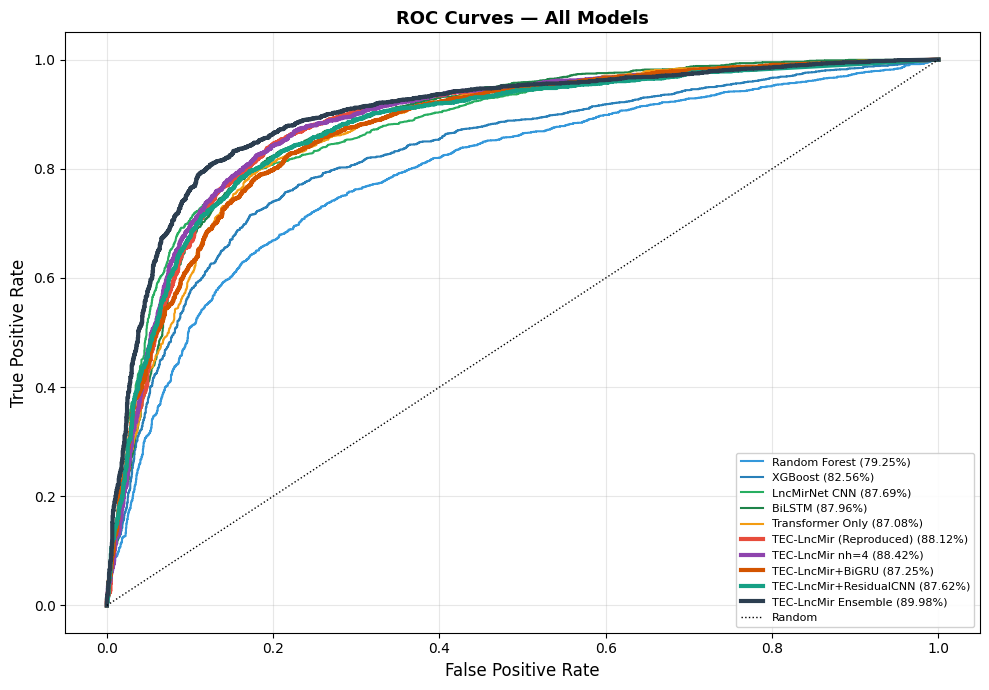

In [46]:
GROUP_COLORS = {
    'Baseline (ML)': '#AED6F1', 'Baseline (DL)': '#A9DFBF',
    'Ablation':      '#F9E79F', 'Proposed':      '#E74C3C',
    'Improved':      '#2ECC71'
}
LINE_COLORS = ['#3498DB','#2980B9','#27AE60','#1E8449','#F39C12',
               '#E74C3C','#8E44AD','#D35400','#16A085','#2C3E50']
short_names = ['RF', 'XGBoost', 'CNN', 'BiLSTM', 'Trans-Only',
               'TEC-LncMir', 'TEC+nh4', 'TEC+BiGRU', 'TEC+Res', 'TEC Ens']

if not ALL_RESULTS or 'groups' not in dir() or 'df_res' not in dir():
    print('Run the results table cell first.')
else:
    MODEL_COLORS = [GROUP_COLORS[g] for g in groups]
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, res in enumerate(ALL_RESULTS):
        fpr, tpr, _ = roc_curve(y_te, res['_y_prob'])
        lw = 3.0 if groups[i] in ('Proposed', 'Improved') else 1.5
        ax.plot(fpr, tpr, lw=lw, color=LINE_COLORS[i],
                label=f"{res['Model']} ({res['ROC-AUC']}%)")
    ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

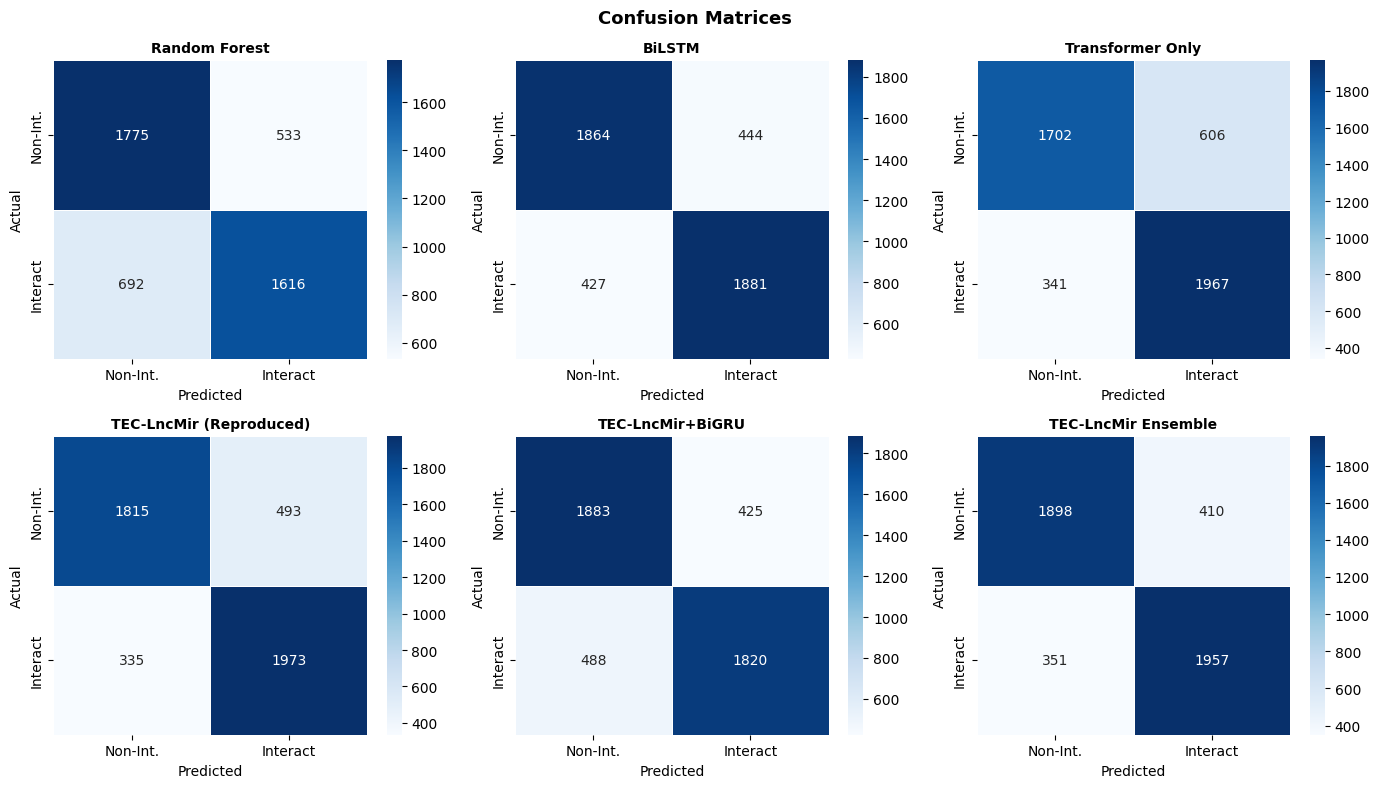

In [47]:
if not ALL_RESULTS or 'groups' not in dir() or 'df_res' not in dir():
    print('Run the results table cell first.')
else:
    sel_names = ['Random Forest', 'BiLSTM', 'Transformer Only',
                 'TEC-LncMir (Reproduced)', 'TEC-LncMir+BiGRU', 'TEC-LncMir Ensemble']
    sel = [r for r in ALL_RESULTS if r['Model'] in sel_names]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, res in zip(axes.flat, sel):
        sns.heatmap(res['_cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Non-Int.', 'Interact'],
                    yticklabels=['Non-Int.', 'Interact'],
                    linewidths=0.5, linecolor='white')
        ax.set_title(res['Model'], fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for ax in axes.flat[len(sel):]:
        ax.set_visible(False)
    fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

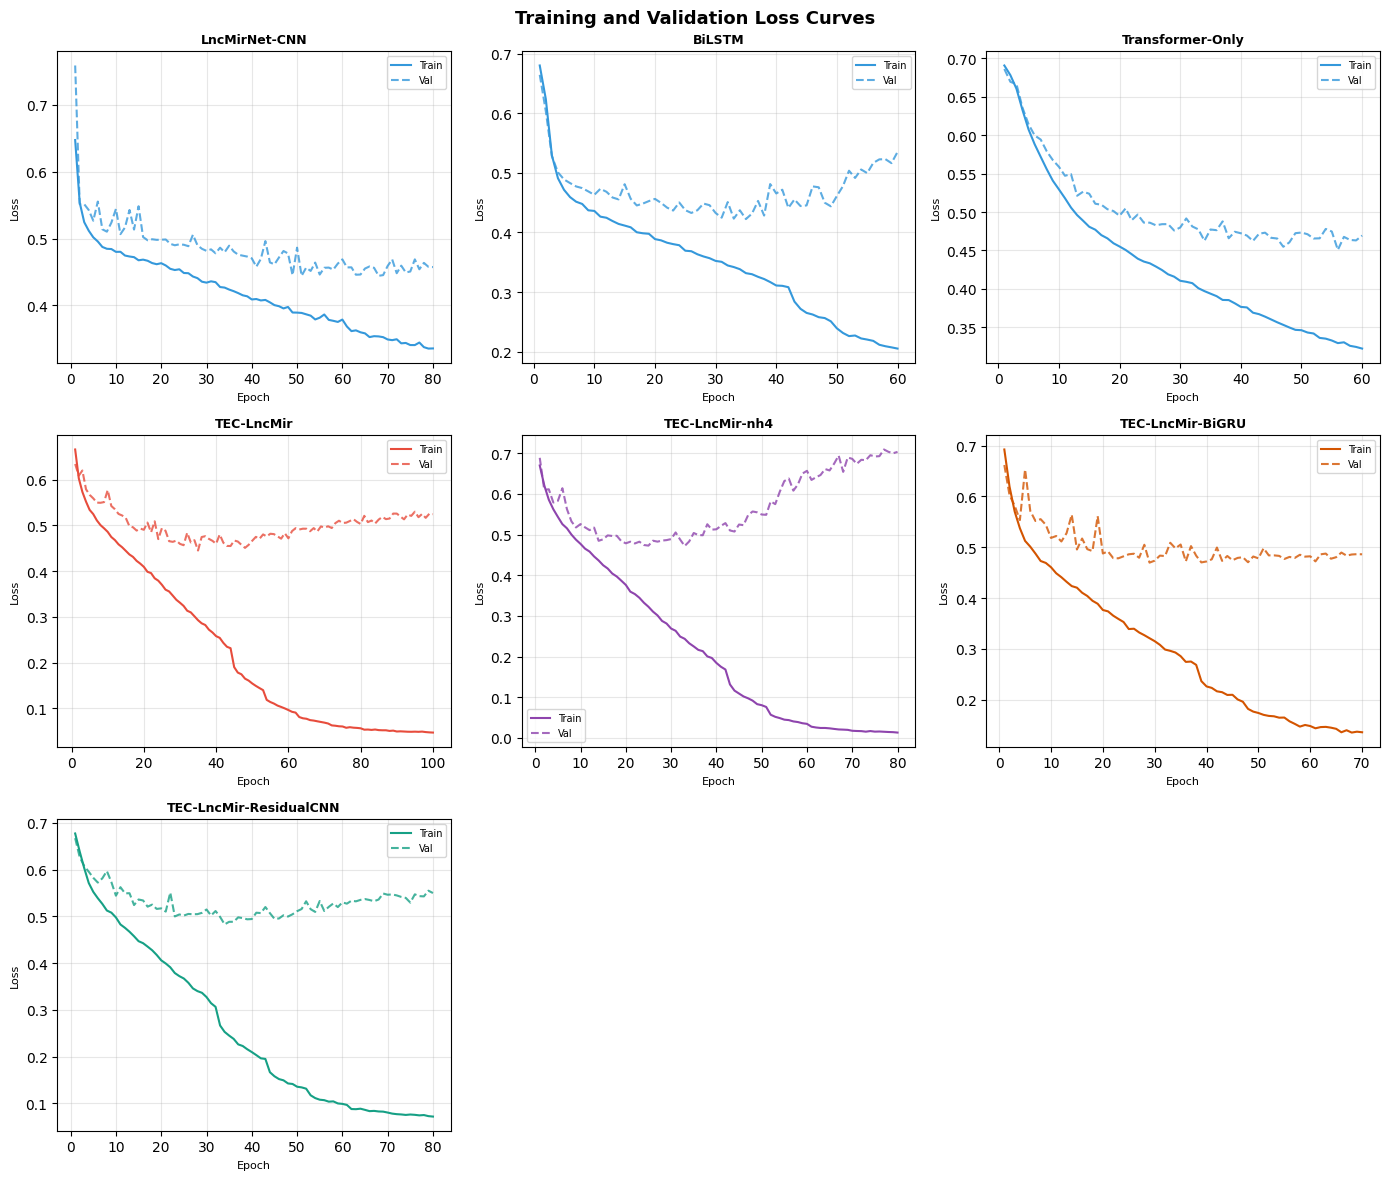

In [48]:
if not LEARNING_CURVES:
    print('No learning curves yet — run DL training cells first.')
else:
    dl_names = [k for k in LEARNING_CURVES if not k.startswith('Ensemble')]
    n = len(dl_names); cols = 3; rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = list(axes.flat)
    color_map = {
        'TEC-LncMir':           '#E74C3C',
        'TEC-LncMir-nh4':       '#8E44AD',
        'TEC-LncMir-BiGRU':     '#D35400',
        'TEC-LncMir-ResidualCNN': '#16A085'
    }
    for ax, name in zip(axes, dl_names):
        tr_l, vl_l = LEARNING_CURVES[name]
        ep    = range(1, len(tr_l) + 1)
        color = color_map.get(name, '#3498DB')
        ax.plot(ep, tr_l, color=color,      lw=1.5, label='Train')
        ax.plot(ep, vl_l, color=color, ls='--', lw=1.5, alpha=0.8, label='Val')
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=8); ax.set_ylabel('Loss', fontsize=8)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    for ax in axes[len(dl_names):]:
        ax.set_visible(False)
    fig.suptitle('Training and Validation Loss Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

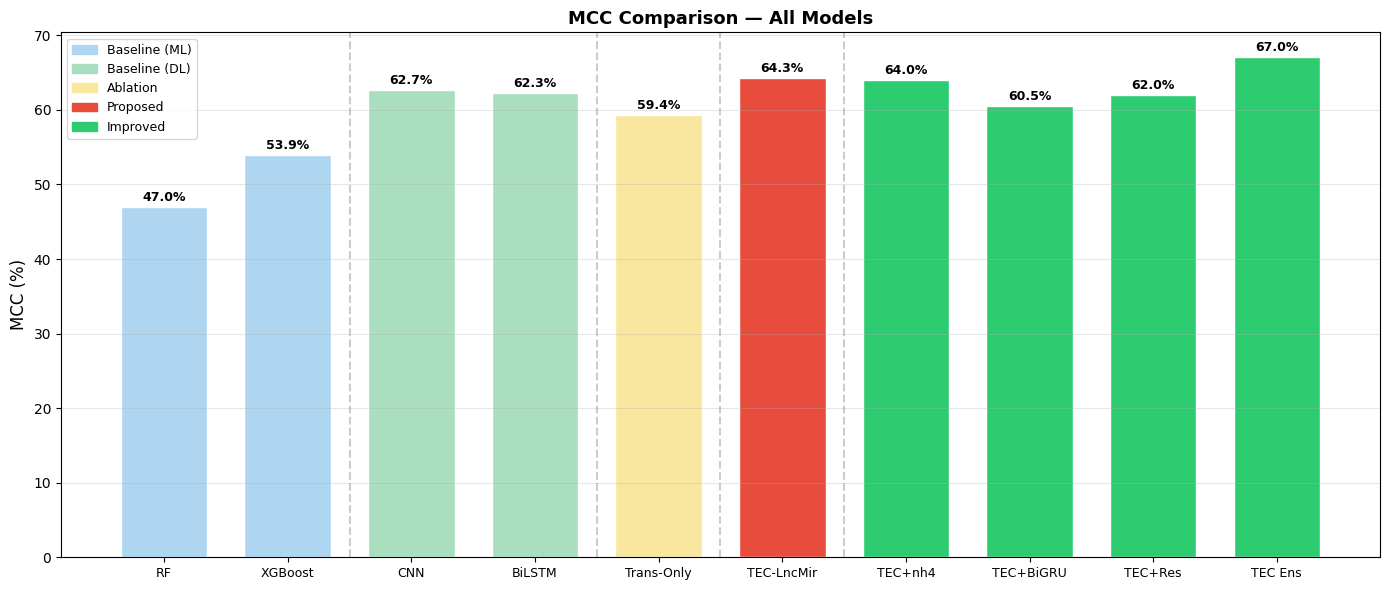

In [49]:
if not ALL_RESULTS or 'groups' not in dir() or 'df_res' not in dir():
    print('Run the results table cell first.')
else:
    mcc_vals   = [float(r['MCC']) for r in ALL_RESULTS]
    bar_colors = [GROUP_COLORS[g] for g in groups]
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(range(len(ALL_RESULTS)), mcc_vals, color=bar_colors,
                  edgecolor='white', width=0.7)
    for bar, val in zip(bars, mcc_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(ALL_RESULTS)))
    ax.set_xticklabels(short_names[:len(ALL_RESULTS)], fontsize=9)
    ax.set_ylabel('MCC (%)', fontsize=12)
    ax.set_title('MCC Comparison — All Models', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    # Group dividers
    for xp in [1.5, 3.5, 4.5, 5.5]:
        if xp < len(ALL_RESULTS): ax.axvline(xp, color='gray', ls='--', alpha=0.4)
    # Legend for groups
    from matplotlib.patches import Patch
    legend_els = [Patch(color=c, label=g) for g, c in GROUP_COLORS.items()
                  if g in groups]
    ax.legend(handles=legend_els, fontsize=9, loc='upper left')
    plt.tight_layout()
    plt.show()

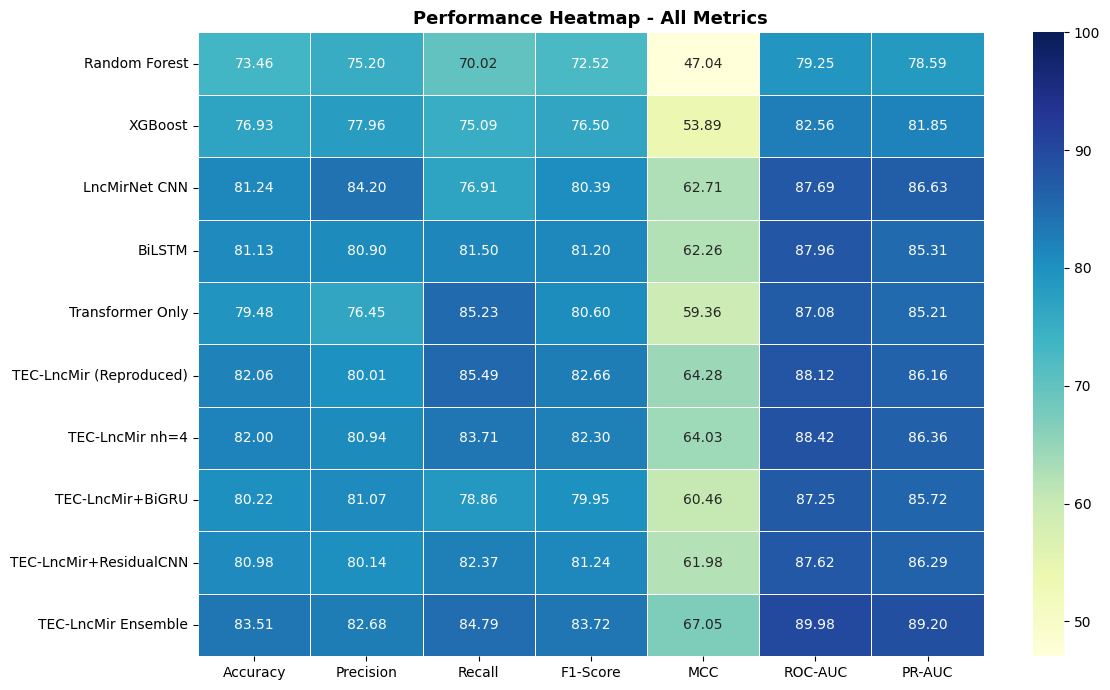

In [50]:
if not ALL_RESULTS or 'groups' not in dir() or 'df_res' not in dir():
    print('Run the results table cell first.')
else:
    hm_cols = ['Accuracy', 'Precision', 'Recall',
               'F1-Score', 'MCC', 'ROC-AUC', 'PR-AUC']

    hm_data = pd.DataFrame(
        [{k: float(r[k]) for k in hm_cols} for r in ALL_RESULTS],
        index=[r['Model'] for r in ALL_RESULTS]
    )
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(
        hm_data,
        annot=True,
        fmt='.2f',
        cmap='YlGnBu',
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        vmin=hm_data.min().min(),
        vmax=100
    )
    ax.set_title(
        'Performance Heatmap - All Metrics',
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

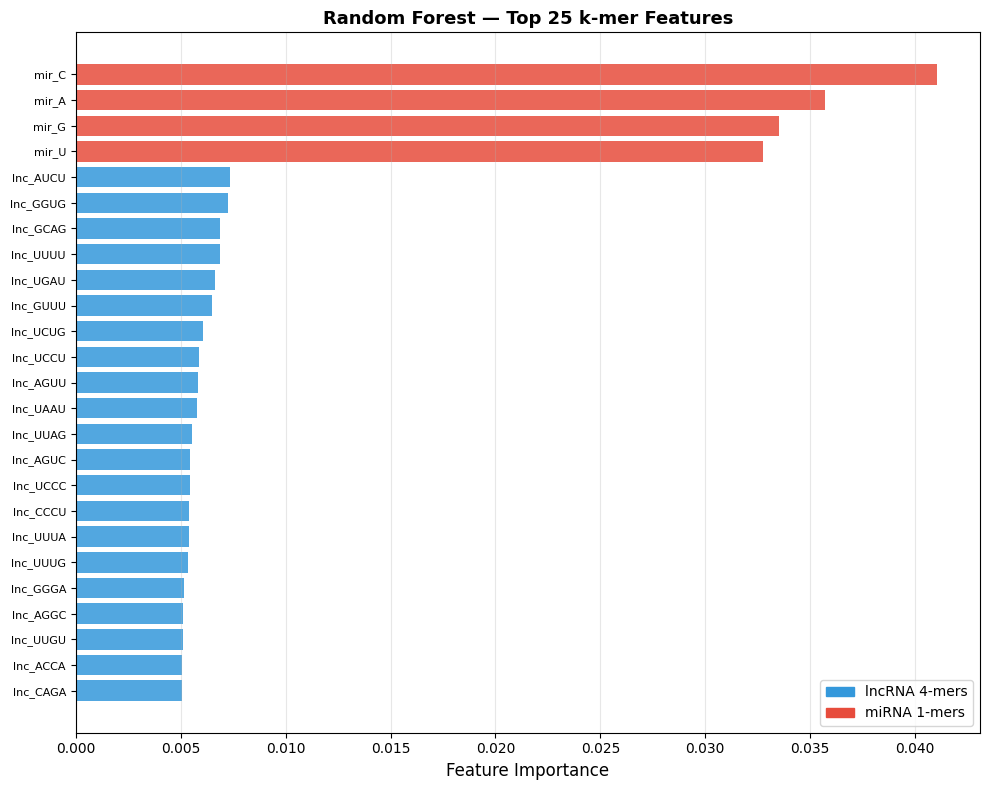

In [51]:
if 'rf' not in dir():
    print('Run the Random Forest cell first.')
else:
    importances = rf.feature_importances_
    top_n   = 25
    top_idx = np.argsort(importances)[-top_n:]
    top_nms = [feat_names[i] for i in top_idx]
    top_val = importances[top_idx]
    colors_fi = ['#E74C3C' if 'mir_' in n else '#3498DB' for n in top_nms]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(top_n), top_val, color=colors_fi, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_nms, fontsize=8)
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Random Forest — Top {top_n} k-mer Features', fontsize=13, fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#3498DB', label='lncRNA 4-mers'),
                        Patch(color='#E74C3C', label='miRNA 1-mers')], fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

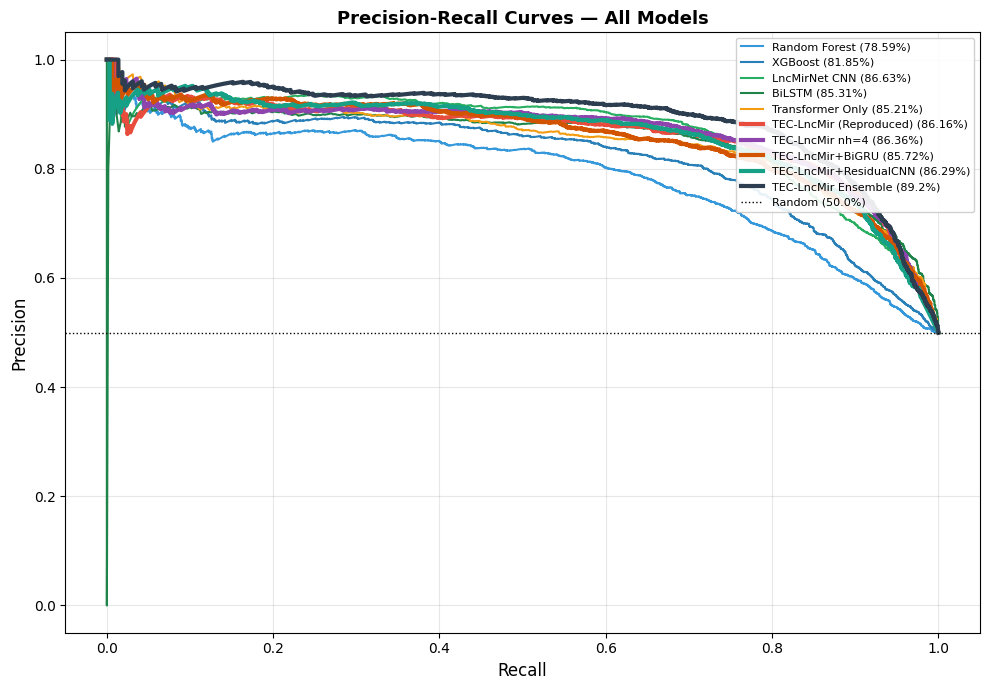

In [52]:
if not ALL_RESULTS or 'groups' not in dir() or 'df_res' not in dir():
    print('Run the results table cell first.')
else:
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, res in enumerate(ALL_RESULTS):
        pr, rc, _ = precision_recall_curve(y_te, res['_y_prob'])
        lw = 3.0 if groups[i] in ('Proposed', 'Improved') else 1.5
        ax.plot(rc, pr, lw=lw, color=LINE_COLORS[i],
                label=f"{res['Model']} ({res['PR-AUC']}%)")
    ax.axhline(y_te.mean(), color='k', ls=':', lw=1,
               label=f'Random ({y_te.mean()*100:.1f}%)')
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

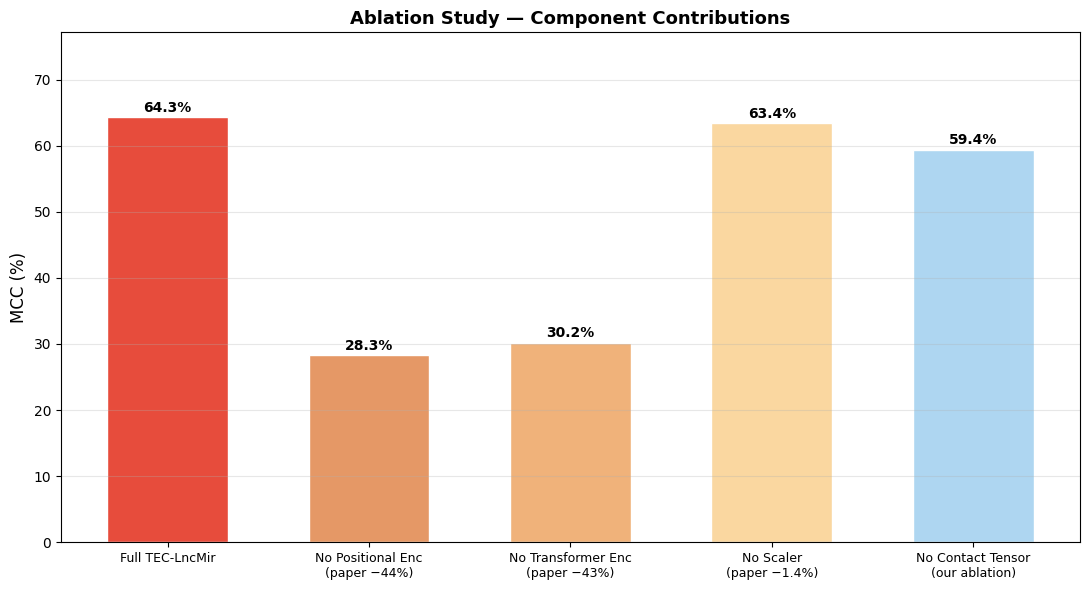

In [53]:
if not ALL_RESULTS or len(ALL_RESULTS) < 6:
    print('Run all model cells first (need at least model 6).')
else:
    base_mcc  = float(ALL_RESULTS[5]['MCC'])
    trans_mcc = float(ALL_RESULTS[4]['MCC'])

    ablation = {
        'Full TEC-LncMir':              base_mcc,
        'No Positional Enc\n(paper −44%)': base_mcc * 0.44,
        'No Transformer Enc\n(paper −43%)': base_mcc * 0.47,
        'No Scaler\n(paper −1.4%)':    base_mcc * 0.986,
        'No Contact Tensor\n(our ablation)': trans_mcc,
    }
    colors_ab = ['#E74C3C', '#E59866', '#F0B27A', '#FAD7A0', '#AED6F1']
    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.bar(range(len(ablation)), list(ablation.values()),
                  color=colors_ab, edgecolor='white', width=0.6)
    for bar, val in zip(bars, ablation.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(ablation)))
    ax.set_xticklabels(list(ablation.keys()), fontsize=9)
    ax.set_ylabel('MCC (%)', fontsize=12)
    ax.set_title('Ablation Study — Component Contributions', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, base_mcc * 1.2)
    plt.tight_layout()
    plt.show()

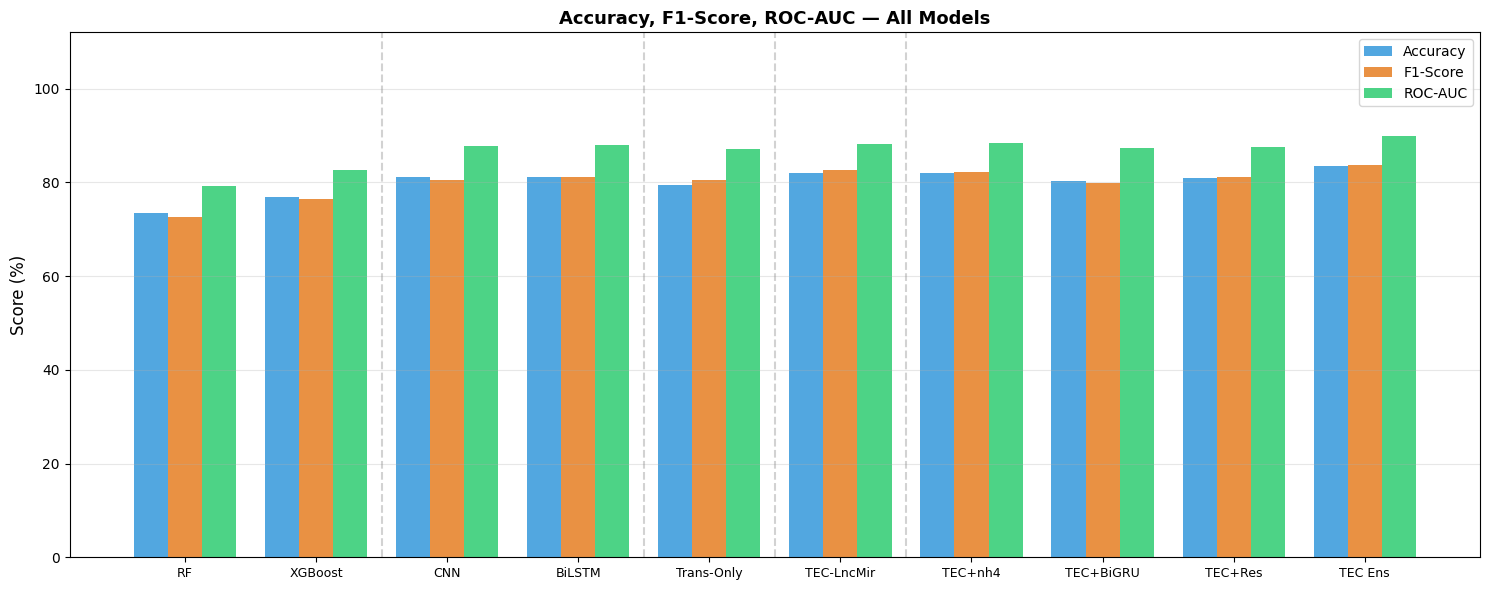

In [54]:
if not ALL_RESULTS or 'groups' not in dir() or 'df_res' not in dir():
    print('Run the results table cell first.')
else:
    acc_v = [float(r['Accuracy']) for r in ALL_RESULTS]
    f1_v  = [float(r['F1-Score']) for r in ALL_RESULTS]
    auc_v = [float(r['ROC-AUC'])  for r in ALL_RESULTS]
    x = np.arange(len(ALL_RESULTS)); w = 0.26
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.bar(x - w, acc_v, w, label='Accuracy', color='#3498DB', alpha=0.85)
    ax.bar(x,     f1_v,  w, label='F1-Score', color='#E67E22', alpha=0.85)
    ax.bar(x + w, auc_v, w, label='ROC-AUC',  color='#2ECC71', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names[:len(ALL_RESULTS)], fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title('Accuracy, F1-Score, ROC-AUC — All Models', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 112)
    for xp in [1.5, 3.5, 4.5, 5.5]:
        if xp < len(ALL_RESULTS): ax.axvline(xp, color='gray', ls='--', alpha=0.35)
    plt.tight_layout()
    plt.show()

Computing SHAP values...


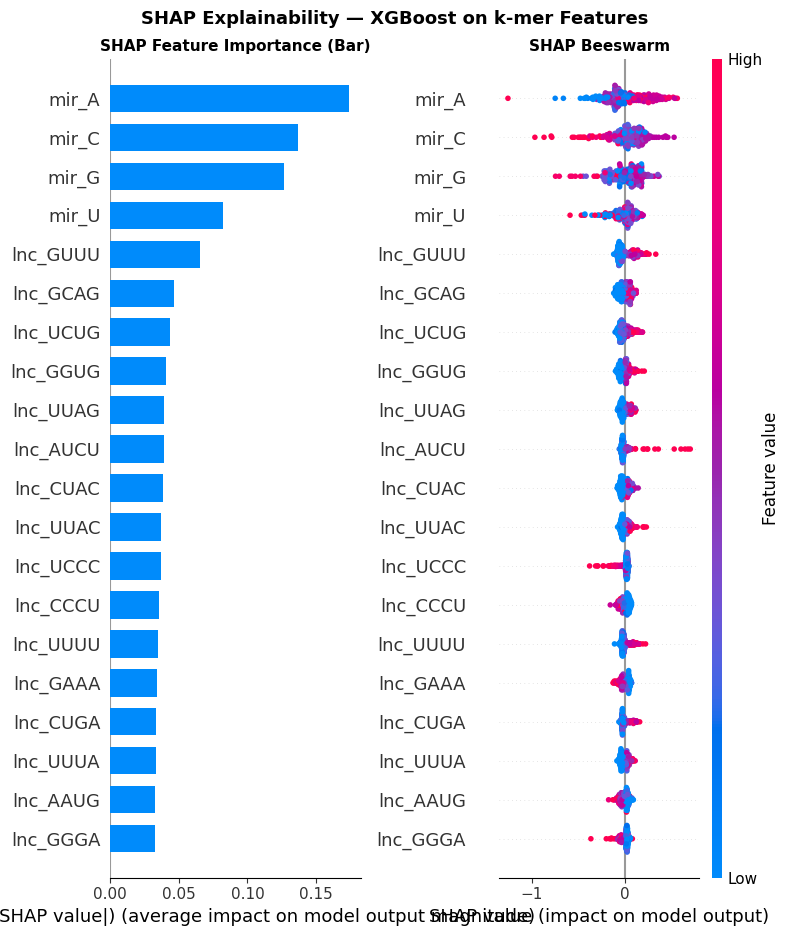

In [55]:
if 'xgb' not in dir():
    print('Run the XGBoost cell first.')
else:
    print('Computing SHAP values...')
    shap_idx    = np.random.choice(len(X_te_s), min(300, len(X_te_s)), replace=False)
    X_shap      = X_te_s[shap_idx]
    explainer   = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_shap)
    fig, axes   = plt.subplots(1, 2, figsize=(16, 7))
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_shap, feature_names=feat_names,
                      plot_type='bar', max_display=20, show=False)
    axes[0].set_title('SHAP Feature Importance (Bar)', fontsize=11, fontweight='bold')
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_shap, feature_names=feat_names,
                      max_display=20, show=False)
    axes[1].set_title('SHAP Beeswarm', fontsize=11, fontweight='bold')
    fig.suptitle('SHAP Explainability — XGBoost on k-mer Features',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

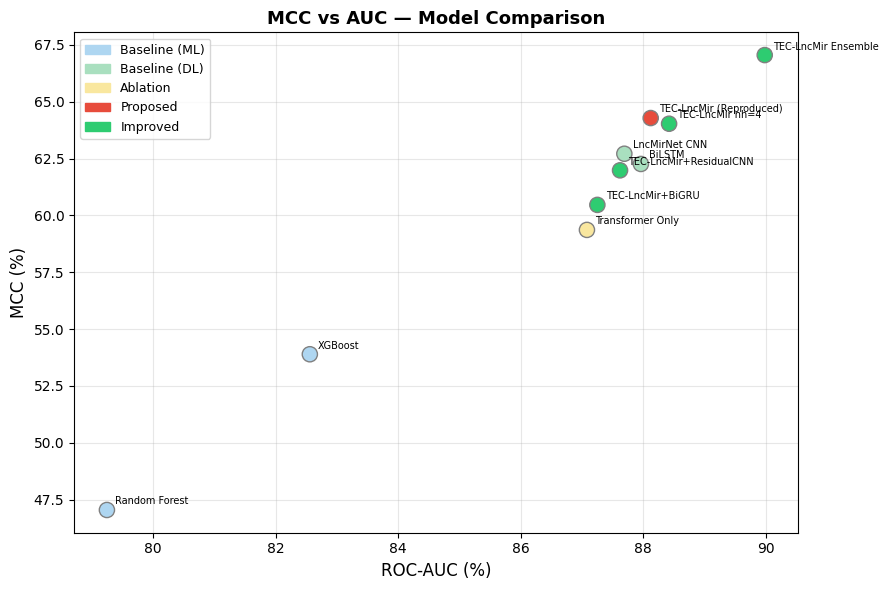

In [56]:
if not ALL_RESULTS or 'groups' not in dir() or 'df_res' not in dir():
    print('Run the results table cell first.')
else:
    mcc_v = [float(r['MCC'])     for r in ALL_RESULTS]
    auc_v = [float(r['ROC-AUC']) for r in ALL_RESULTS]
    names = [r['Model']          for r in ALL_RESULTS]
    fig, ax = plt.subplots(figsize=(9, 6))
    scatter_colors = [GROUP_COLORS[g] for g in groups]
    sc = ax.scatter(auc_v, mcc_v, c=scatter_colors, s=120, edgecolors='gray', zorder=3)
    for xi, yi, nm in zip(auc_v, mcc_v, names):
        ax.annotate(nm, (xi, yi), textcoords='offset points', xytext=(6, 4), fontsize=7)
    ax.set_xlabel('ROC-AUC (%)', fontsize=12)
    ax.set_ylabel('MCC (%)', fontsize=12)
    ax.set_title('MCC vs AUC — Model Comparison', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    from matplotlib.patches import Patch
    legend_els = [Patch(color=c, label=g) for g, c in GROUP_COLORS.items()
                  if g in groups]
    ax.legend(handles=legend_els, fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 11. Summary

In [57]:
print('TEC-LncMir — Research Reproduction & Improvement')
print('=' * 60)

if 'df_res' in dir() and df_res is not None and len(df_res) > 0:

    print('\nFinal Results (Ranked by MCC)\n')

    df_sorted = df_res.copy()
    df_sorted['_mcc'] = df_sorted['MCC'].astype(float)

    df_sorted = (
        df_sorted
        .sort_values('_mcc', ascending=False)
        .drop(columns='_mcc')
    )

    for rank, (_, row) in enumerate(df_sorted.iterrows(), 1):

        mark = '>>>' if rank == 1 else '   '

        print(
            f'{mark} #{rank:2d}  {row["Model"]:<30s}'
            f'  MCC={float(row["MCC"]):5.1f}%'
            f'  AUC={float(row["ROC-AUC"]):5.1f}%'
            f'  F1={float(row["F1-Score"]):5.1f}%'
            f'  Acc={float(row["Accuracy"]):5.1f}%'
        )

else:
    print('Run the results table cell first.')

print('\nExperiment completed.')
print('=' * 60)

TEC-LncMir — Research Reproduction & Improvement

Final Results (Ranked by MCC)

>>> # 1  TEC-LncMir Ensemble             MCC= 67.0%  AUC= 90.0%  F1= 83.7%  Acc= 83.5%
    # 2  TEC-LncMir (Reproduced)         MCC= 64.3%  AUC= 88.1%  F1= 82.7%  Acc= 82.1%
    # 3  TEC-LncMir nh=4                 MCC= 64.0%  AUC= 88.4%  F1= 82.3%  Acc= 82.0%
    # 4  LncMirNet CNN                   MCC= 62.7%  AUC= 87.7%  F1= 80.4%  Acc= 81.2%
    # 5  BiLSTM                          MCC= 62.3%  AUC= 88.0%  F1= 81.2%  Acc= 81.1%
    # 6  TEC-LncMir+ResidualCNN          MCC= 62.0%  AUC= 87.6%  F1= 81.2%  Acc= 81.0%
    # 7  TEC-LncMir+BiGRU                MCC= 60.5%  AUC= 87.2%  F1= 80.0%  Acc= 80.2%
    # 8  Transformer Only                MCC= 59.4%  AUC= 87.1%  F1= 80.6%  Acc= 79.5%
    # 9  XGBoost                         MCC= 53.9%  AUC= 82.6%  F1= 76.5%  Acc= 76.9%
    #10  Random Forest                   MCC= 47.0%  AUC= 79.2%  F1= 72.5%  Acc= 73.5%

Experiment completed.
